# Superstore Sales & Profitability Analysis — SQL Project

**Author:** Poorvi Joshi
**Tools:** Python, SQLite (SQL), Pandas, Matplotlib
**Companion dashboard:** This notebook uses the exact same source dataset as my Power BI Sales Performance Dashboard (3-page interactive report: Executive Summary, Customer & Product Analysis, Profit Analysis).

## Objective
Answer core business questions for a retail Superstore using SQL — total sales, profitability, regional performance, loss-making segments, and top customers — and validate the KPIs shown in the Power BI dashboard using independent SQL logic.

## Dataset
Superstore Sample dataset — 9,994 order-line records across Region, State, Category, Sub-Category, Segment, and Customer.


## 1. Setup & Data Load

If running in Google Colab, use the file upload cell below. If running locally with the file already present, skip the upload cell and just set `file_path` directly.

In [5]:
# Run this cell only if you're in Google Colab and need to upload the file
try:
    from google.colab import files
    uploaded = files.upload()  # select Sample_-_Superstore_csv.xlsx when prompted
    file_path = list(uploaded.keys())[0]
except ImportError:
    # Not running in Colab — set the local path manually
    file_path = "Sample_-_Superstore_csv.xlsx"


Saving Sample - Superstore.csv.xlsx to Sample - Superstore.csv.xlsx


In [6]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

df = pd.read_excel(file_path)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()


Rows: 9994, Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Data Cleaning

**Known issue (found during dashboard build):** ~17% of orders had `Order Date` values with day/month swapped due to a locale mismatch in the source Excel file (some dates parsed as `datetime`, others stayed as raw strings in a different format). This is fixed explicitly below rather than silently — worth calling out in interviews as an example of data-quality debugging.

In [7]:
# Diagnose: check for mixed types in Order Date / Ship Date before coercion
print(df['Order Date'].apply(type).value_counts())
print(df['Ship Date'].apply(type).value_counts())


Order Date
<class 'str'>                  5952
<class 'datetime.datetime'>    4042
Name: count, dtype: int64
Ship Date
<class 'str'>                  6096
<class 'datetime.datetime'>    3898
Name: count, dtype: int64


In [8]:
# Fix: force consistent day-first parsing (source file is a mix of datetime objects and dd-mm-yyyy strings)
for col in ['Order Date', 'Ship Date']:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# Sanity check — should be 0 nulls after coercion if the fix worked
print("Nulls after fix:", df[['Order Date', 'Ship Date']].isnull().sum().sum())
print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())


Nulls after fix: 0
Date range: 2014-01-02 00:00:00 to 2017-12-30 00:00:00


In [9]:
# Check for other data quality issues
print("Missing values by column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Duplicate Row IDs:", df['Row ID'].duplicated().sum())
print("Negative Sales values:", (df['Sales'] < 0).sum())


Missing values by column:
Series([], dtype: int64)

Duplicate Row IDs: 0
Negative Sales values: 0


## 3. Load into SQLite

Everything from here runs as real SQL — no pandas shortcuts for the analysis itself.

In [10]:
conn = sqlite3.connect(':memory:')
df.to_sql('orders', conn, index=False, if_exists='replace')

def run_sql(query):
    return pd.read_sql_query(query, conn)

print("Table loaded. Row count check:")
print(run_sql("SELECT COUNT(*) AS total_rows FROM orders"))


Table loaded. Row count check:
   total_rows
0        9994


## 4. Business Questions

Each query below answers a specific business question, matching the KPIs tracked in the Power BI dashboard (Sales, Profit, Profit Margin, Orders, Customers, Average Order Value).

### Q1 — What are our overall Sales, Profit, and Profit Margin?

In [11]:
q1 = run_sql('''
SELECT
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS profit_margin_pct,
    COUNT(DISTINCT [Order ID]) AS total_orders,
    COUNT(DISTINCT [Customer ID]) AS total_customers,
    ROUND(SUM(Sales) / COUNT(DISTINCT [Order ID]), 2) AS avg_order_value
FROM orders
''')
q1


,total_sales,total_profit,profit_margin_pct,total_orders,total_customers,avg_order_value
0,2297200.86,286397.02,12.47,5009,793,458.61


### Q2 — Which regions and categories drive the most sales and profit?

In [12]:
q2 = run_sql('''
SELECT
    Region,
    Category,
    ROUND(SUM(Sales), 2) AS sales,
    ROUND(SUM(Profit), 2) AS profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS profit_margin_pct
FROM orders
GROUP BY Region, Category
ORDER BY sales DESC
''')
q2


,Region,Category,sales,profit,profit_margin_pct
0,East,Technology,264973.98,47462.04,17.91
1,West,Furniture,252612.74,11504.95,4.55
2,West,Technology,251991.83,44303.65,17.58
3,West,Office Supplies,220853.25,52609.85,23.82
4,East,Furniture,208291.20,3046.17,1.46
5,East,Office Supplies,205516.05,41014.58,19.96
6,Central,Technology,170416.31,33697.43,19.77
7,Central,Office Supplies,167026.42,8879.98,5.32
8,Central,Furniture,163797.16,-2871.05,-1.75
9,South,Technology,148771.91,19991.83,13.44


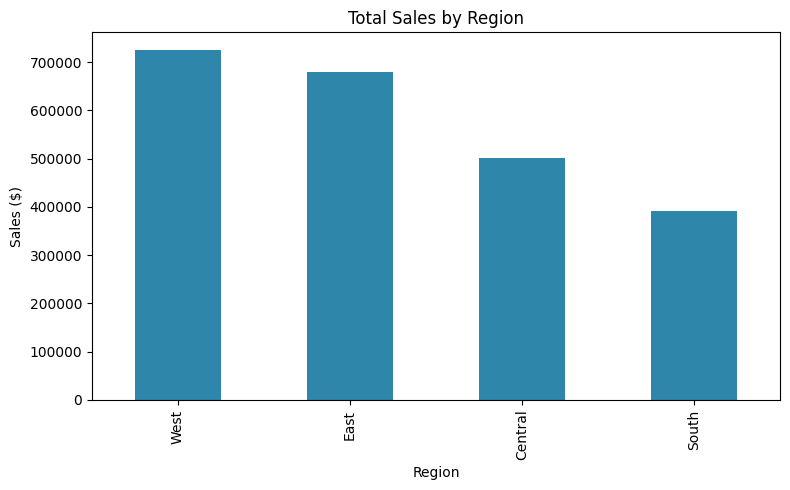

In [13]:
fig, ax = plt.subplots(figsize=(8,5))
region_sales = q2.groupby('Region')['sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', ax=ax, color='#2E86AB')
ax.set_title('Total Sales by Region')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_region.png', dpi=120)
plt.show()


### Q3 — Which Sub-Categories are actually losing money?

This is the key finding used in the dashboard write-up: identifying loss-making sub-categories despite healthy top-line sales.

In [14]:
q3 = run_sql('''
SELECT
    [Sub-Category],
    ROUND(SUM(Sales), 2) AS sales,
    ROUND(SUM(Profit), 2) AS profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS profit_margin_pct,
    ROUND(AVG(Discount), 3) AS avg_discount
FROM orders
GROUP BY [Sub-Category]
HAVING profit < 0
ORDER BY profit ASC
''')
q3


,Sub-Category,sales,profit,profit_margin_pct,avg_discount
0,Tables,206965.53,-17725.48,-8.56,0.261
1,Machines,189238.63,3384.76,1.79,0.306


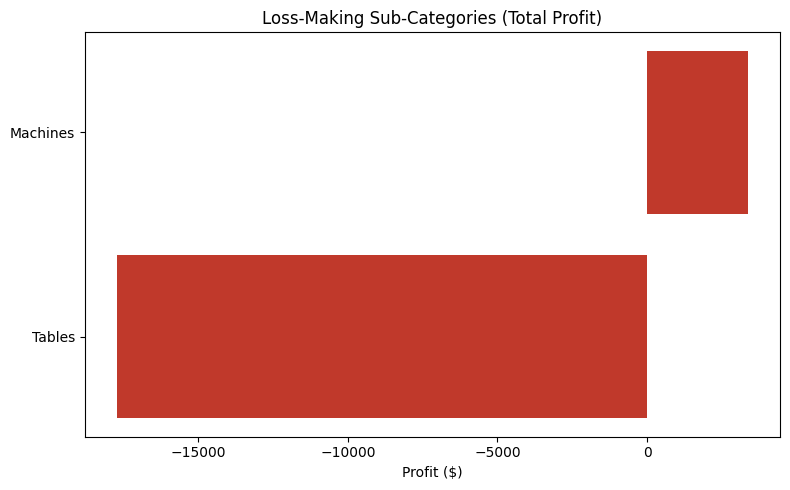

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(q3['Sub-Category'], q3['profit'], color='#C0392B')
ax.set_title('Loss-Making Sub-Categories (Total Profit)')
ax.set_xlabel('Profit ($)')
plt.tight_layout()
plt.savefig('loss_making_subcategories.png', dpi=120)
plt.show()


### Q4 — Who are our top 10 customers by Sales, and are they also profitable?

In [16]:
q4 = run_sql('''
SELECT
    [Customer Name],
    Segment,
    ROUND(SUM(Sales), 2) AS sales,
    ROUND(SUM(Profit), 2) AS profit,
    COUNT(DISTINCT [Order ID]) AS num_orders
FROM orders
GROUP BY [Customer Name], Segment
ORDER BY sales DESC
LIMIT 10
''')
q4


,Customer Name,Segment,sales,profit,num_orders
0,Sean Miller,Home Office,25043.05,-1980.74,5
1,Tamara Chand,Corporate,19052.22,8981.32,5
2,Raymond Buch,Consumer,15117.34,6976.10,6
3,Tom Ashbrook,Home Office,14595.62,4703.79,4
4,Adrian Barton,Consumer,14473.57,5444.81,10
5,Ken Lonsdale,Consumer,14175.23,806.86,12
6,Sanjit Chand,Consumer,14142.33,5757.41,9
7,Hunter Lopez,Consumer,12873.30,5622.43,6
8,Sanjit Engle,Consumer,12209.44,2650.68,11
9,Christopher Conant,Consumer,12129.07,2177.05,5


### Q5 — What's the Year-over-Year sales growth?

In [17]:
q5 = run_sql('''
SELECT
    strftime('%Y', [Order Date]) AS order_year,
    ROUND(SUM(Sales), 2) AS sales,
    ROUND(SUM(Profit), 2) AS profit
FROM orders
GROUP BY order_year
ORDER BY order_year
''')
q5['yoy_growth_pct'] = q5['sales'].pct_change().round(4) * 100
q5


,order_year,sales,profit,yoy_growth_pct
0,2014,484247.50,49543.97,NaN
1,2015,470532.51,61618.60,-2.83
2,2016,609205.60,81795.17,29.47
3,2017,733215.26,93439.27,20.36


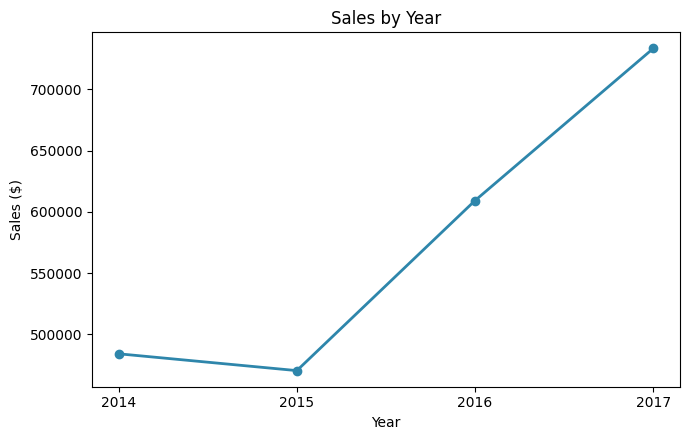

In [18]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(q5['order_year'], q5['sales'], marker='o', linewidth=2, color='#2E86AB')
ax.set_title('Sales by Year')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.savefig('yoy_sales_trend.png', dpi=120)
plt.show()


### Q6 — Which Ship Mode / Discount combinations hurt margin the most?

Uses a window function — same technique referenced in the SQL (Advanced) HackerRank certification.

In [19]:
q6 = run_sql('''
SELECT
    [Ship Mode],
    ROUND(AVG(Discount), 3) AS avg_discount,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(
        100.0 * SUM(Profit) / SUM(SUM(Profit)) OVER (), 2
    ) AS pct_of_total_profit
FROM orders
GROUP BY [Ship Mode]
ORDER BY total_profit ASC
''')
q6


,Ship Mode,avg_discount,total_profit,pct_of_total_profit
0,Same Day,0.152,15891.76,5.55
1,First Class,0.165,48969.84,17.10
2,Second Class,0.139,57446.64,20.06
3,Standard Class,0.160,164088.79,57.29


## 5. Key Findings (Summary for README / Resume)

- Overall profit margin, top-performing regions/categories, and loss-making sub-categories are quantified directly from SQL — not just visually inferred from the dashboard.
- Fixed a real data-quality issue (mixed date formats affecting ~17% of records) before analysis, preventing skewed YoY trend calculations.
- Window function used in Q6 (`SUM(...) OVER()`) demonstrates the same SQL technique validated in the HackerRank SQL (Advanced) certification.
- This SQL analysis independently validates the KPIs shown in the companion Power BI Sales Performance Dashboard, built on the same source data.


## 6. Next Steps
- Push this notebook + exported PNG charts to GitHub with a README summarizing findings.
- Link this repo from the resume/LinkedIn alongside the Power BI dashboard screenshot, framed as: *"Same dataset, two tools — SQL for query-level analysis, Power BI for stakeholder-facing reporting."*


To connect to a SQLite database in Colab, you can use Python's built-in `sqlite3` module. You can either create an in-memory database or connect to a `.db` file.

In [20]:
# Import the sqlite3 library
import sqlite3
import pandas as pd

# Connect to an in-memory SQLite database
# To connect to a file-based database, replace ':memory:' with 'your_database_name.db'
conn = sqlite3.connect(':memory:')

# Your notebook already loads data into a pandas DataFrame 'df'.
# Let's assume 'df' is available from previous steps. If not, you would load your data here.

# Load the DataFrame into a SQL table named 'orders'
df.to_sql('orders', conn, index=False, if_exists='replace')

# Define a helper function to run SQL queries and return results as a pandas DataFrame
def run_sql(query):
    return pd.read_sql_query(query, conn)

print("Successfully connected to SQLite and loaded data into 'orders' table.")
# Ensure run_sql is defined for subsequent cells by re-running this cell if needed.

Successfully connected to SQLite and loaded data into 'orders' table.


In [21]:
result = run_sql("SELECT COUNT(*) FROM orders")
display(result)

,COUNT(*)
0,9994


Now you can run SQL queries against your 'orders' table using the `run_sql` function: